# Wave-U-Net receiver-held-out Noise2Self denoising of the supplied noisy gather

This notebook applies the nine-scale Wave-U-Net Noise2Self method to the
existing `dmulti_receiver_data_noisy_2db.bin` seismic gather. For each target
receiver, its **entire trace is hidden** from the model. Eight fixed-offset
neighbour traces and eight availability masks form the input; the hidden noisy
trace is the self-supervised target.

Only the supplied noisy gather is used for normalization, training, validation,
early stopping, checkpoint selection, and inference. The clean gather is read
only at the end for synthetic-data evaluation.


In [1]:
from pathlib import Path
import copy
import math
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

N_TRACES = 100
N_SAMPLES = 4000
DT = 0.001
DTYPE = np.float32
EXPECTED_VALUES = N_TRACES * N_SAMPLES

SEED = 42
RECEIVER_OFFSETS = (-4, -3, -2, -1, 1, 2, 3, 4)
N_NEIGHBORS = len(RECEIVER_OFFSETS)
INPUT_CHANNELS = 2 * N_NEIGHBORS

TRAIN_END = 3328
VALIDATION_START = 3488
TRAIN_PATCH_LENGTH = 1024
TRAIN_PATCH_STRIDE = 256
VALIDATION_PATCH_LENGTH = N_SAMPLES - VALIDATION_START

BATCH_SIZE = 16
INFERENCE_BATCH_SIZE = 10
MAX_EPOCHS = 60
EARLY_STOPPING_PATIENCE = 5
MODEL_SELECTION_WARMUP_EPOCHS = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 3.0

MODEL_CONFIG = {
    "input_channels": INPUT_CHANNELS,
    "output_channels": 1,
    "num_layers": 9,
    "num_initial_filters": 24,
    "filter_size": 15,
    "merge_filter_size": 5,
}

SOURCE_REPOSITORY = (
    "https://github.com/craigmacartney/"
    "Wave-U-Net-For-Speech-Enhancement"
)
SOURCE_COMMIT = "c8ccbd286cbe73d7539e5703e4407762304e3068"

torch.set_num_threads(min(8, os.cpu_count() or 1))
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is required. Run this notebook in the 'vk' conda environment "
        "on a CUDA-enabled machine."
    )
DEVICE = torch.device("cuda")
AMP_ENABLED = True

candidate_dirs = [Path.cwd(), Path.cwd() / "Denoise_master"]
DATA_DIR = next(
    (
        directory
        for directory in candidate_dirs
        if (directory / "dmulti_receiver_data_noisy_2db.bin").is_file()
    ),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find dmulti_receiver_data_noisy_2db.bin in the current "
        "directory or in ./Denoise_master."
    )

NOISY_PATH = DATA_DIR / "dmulti_receiver_data_noisy_2db.bin"
CLEAN_REFERENCE_PATH = DATA_DIR / "dmulti_receiver_data.bin"
CHECKPOINT_PATH = DATA_DIR / "waveunet_noise2self_noisy_input_model.pt"

gpu = torch.cuda.get_device_properties(0)
print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"GPU: {gpu.name} ({gpu.total_memory / 2**30:.2f} GiB)")
print(f"Noisy input: {NOISY_PATH.resolve()}")
print(f"Checkpoint: {CHECKPOINT_PATH.resolve()}")
print("The denoised gather remains in memory; no denoised .bin is written.")


PyTorch: 2.9.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 3090 (23.57 GiB)
Noisy input: /mnt/drive/adarsh/MBD/Denoise_master/dmulti_receiver_data_noisy_2db.bin
Checkpoint: /mnt/drive/adarsh/MBD/Denoise_master/waveunet_noise2self_noisy_input_model.pt
The denoised gather remains in memory; no denoised .bin is written.


## 1. Load and normalize only the supplied noisy gather

The clean reference path is deliberately not opened in this section.


In [2]:
raw = np.fromfile(NOISY_PATH, dtype=DTYPE)
if raw.size != EXPECTED_VALUES:
    raise ValueError(
        f"Expected {EXPECTED_VALUES:,} float32 values, found {raw.size:,}."
    )
if not np.isfinite(raw).all():
    raise ValueError("The noisy gather contains NaN or infinite values.")

noisy = raw.reshape(N_TRACES, N_SAMPLES)
time_s = np.arange(N_SAMPLES) * DT

normalization_mean = float(noisy.mean(dtype=np.float64))
normalization_scale = float(noisy.std(dtype=np.float64))
if not np.isfinite(normalization_scale) or normalization_scale <= 0:
    raise ValueError("The noisy-gather standard deviation must be positive.")

noisy_normalized = (
    (noisy.astype(np.float64) - normalization_mean) / normalization_scale
).astype(np.float32)

assert noisy.shape == (N_TRACES, N_SAMPLES)
assert np.isfinite(noisy_normalized).all()

print(f"Noisy gather shape: {noisy.shape}")
print(f"Trace duration: {N_SAMPLES * DT:.3f} s")
print(f"Noisy-only normalization mean: {normalization_mean:.8g}")
print(f"Noisy-only normalization scale: {normalization_scale:.8g}")


Noisy gather shape: (100, 4000)
Trace duration: 4.000 s
Noisy-only normalization mean: -1.0371203e-06
Noisy-only normalization scale: 0.023867207


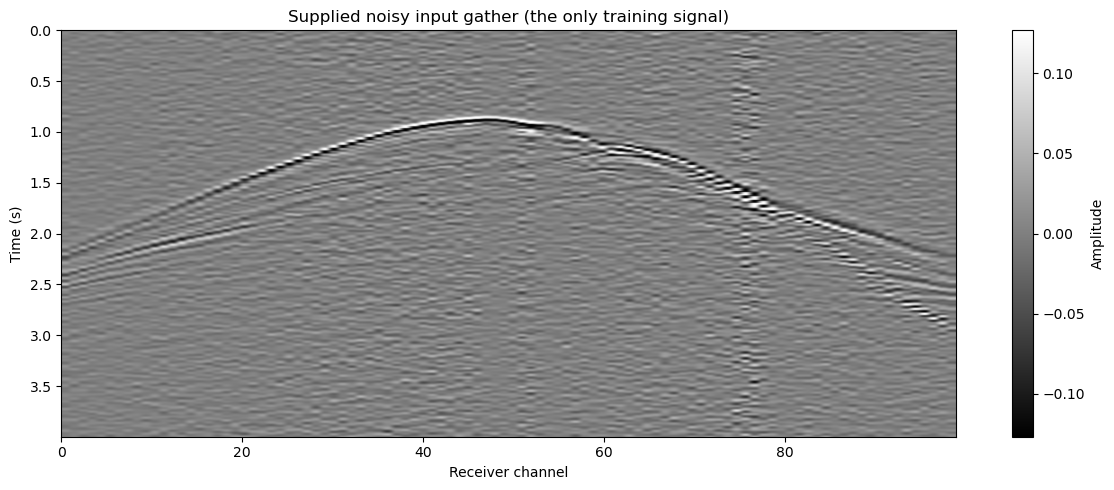

In [3]:
clip = np.quantile(np.abs(noisy), 0.995)
plt.figure(figsize=(12, 5))
plt.imshow(
    noisy.T,
    aspect="auto",
    cmap="gray",
    vmin=-clip,
    vmax=clip,
    extent=[0, N_TRACES - 1, time_s[-1], time_s[0]],
)
plt.colorbar(label="Amplitude")
plt.xlabel("Receiver channel")
plt.ylabel("Time (s)")
plt.title("Supplied noisy input gather (the only training signal)")
plt.tight_layout()
plt.show()


## 2. Build strictly target-free receiver inputs

The first eight channels contain neighbouring traces. The next eight are
binary availability masks. A missing receiver offset is represented by zeros
in both its signal and mask channel.

In [4]:
def build_masked_neighbor_inputs(normalized_gather):
    normalized_gather = np.asarray(normalized_gather, dtype=np.float32)
    if normalized_gather.shape != (N_TRACES, N_SAMPLES):
        raise ValueError(
            f"Expected {(N_TRACES, N_SAMPLES)}, got "
            f"{normalized_gather.shape}."
        )

    signals = np.zeros(
        (N_TRACES, N_NEIGHBORS, N_SAMPLES), dtype=np.float32
    )
    masks = np.zeros_like(signals)
    for target_receiver in range(N_TRACES):
        for channel, offset in enumerate(RECEIVER_OFFSETS):
            source_receiver = target_receiver + offset
            if 0 <= source_receiver < N_TRACES:
                signals[target_receiver, channel] = normalized_gather[
                    source_receiver
                ]
                masks[target_receiver, channel] = 1.0

    return np.ascontiguousarray(
        np.concatenate((signals, masks), axis=1), dtype=np.float32
    )


neighbor_inputs = build_masked_neighbor_inputs(noisy_normalized)
targets = np.ascontiguousarray(noisy_normalized[:, None, :])

assert neighbor_inputs.shape == (N_TRACES, INPUT_CHANNELS, N_SAMPLES)
assert targets.shape == (N_TRACES, 1, N_SAMPLES)
assert np.isfinite(neighbor_inputs).all()
assert np.isfinite(targets).all()

available_counts = neighbor_inputs[:, N_NEIGHBORS:, 0].sum(axis=1)
print(f"Model inputs: {neighbor_inputs.shape}")
print(f"Targets: {targets.shape}")
print(f"Receiver offsets: {RECEIVER_OFFSETS}")
print(
    "Available neighbours per target: "
    f"min={available_counts.min():.0f}, max={available_counts.max():.0f}"
)

Model inputs: (100, 16, 4000)
Targets: (100, 1, 4000)
Receiver offsets: (-4, -3, -2, -1, 1, 2, 3, 4)
Available neighbours per target: min=4, max=8


In [5]:
# Data-level J-invariance test for every receiver, including gather edges.
perturbation_rng = np.random.default_rng(2024)
perturbed_target_inputs = []
maximum_target_input_difference = 0.0

for target_receiver in range(N_TRACES):
    perturbed = noisy_normalized.copy()
    perturbed[target_receiver] += (
        10.0
        * perturbation_rng.standard_normal(N_SAMPLES).astype(np.float32)
    )
    rebuilt = build_masked_neighbor_inputs(perturbed)
    target_input = rebuilt[target_receiver]
    maximum_target_input_difference = max(
        maximum_target_input_difference,
        float(np.max(np.abs(target_input - neighbor_inputs[target_receiver]))),
    )
    perturbed_target_inputs.append(target_input)

perturbed_target_inputs = np.ascontiguousarray(
    np.stack(perturbed_target_inputs), dtype=np.float32
)
assert maximum_target_input_difference == 0.0
assert np.array_equal(perturbed_target_inputs, neighbor_inputs)

print("All-receiver target-exclusion test passed.")
print(
    "Maximum target-input difference after perturbation: "
    f"{maximum_target_input_difference:.3g}"
)

All-receiver target-exclusion test passed.
Maximum target-input difference after perturbation: 0


In [6]:
train_starts = np.arange(
    0,
    TRAIN_END - TRAIN_PATCH_LENGTH + 1,
    TRAIN_PATCH_STRIDE,
    dtype=int,
)
validation_starts = np.array([VALIDATION_START], dtype=int)


class ReceiverPatchDataset(Dataset):
    def __init__(self, inputs, model_targets, starts, patch_length):
        self.inputs = inputs
        self.targets = model_targets
        self.patch_length = patch_length
        self.items = [
            (receiver, int(start))
            for receiver in range(N_TRACES)
            for start in starts
        ]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, index):
        receiver, start = self.items[index]
        stop = start + self.patch_length
        x = torch.from_numpy(self.inputs[receiver, :, start:stop])
        y = torch.from_numpy(self.targets[receiver, :, start:stop])
        return x, y


train_dataset = ReceiverPatchDataset(
    neighbor_inputs, targets, train_starts, TRAIN_PATCH_LENGTH
)
validation_dataset = ReceiverPatchDataset(
    neighbor_inputs,
    targets,
    validation_starts,
    VALIDATION_PATCH_LENGTH,
)

assert train_starts[-1] + TRAIN_PATCH_LENGTH <= TRAIN_END
assert TRAIN_END < VALIDATION_START
assert VALIDATION_START + VALIDATION_PATCH_LENGTH == N_SAMPLES

print(f"Training starts: {train_starts.tolist()}")
print(f"Training patches: {len(train_dataset):,}")
print(f"Validation interval: [{VALIDATION_START}:{N_SAMPLES}]")
print(f"Validation patches: {len(validation_dataset):,}")

Training starts: [0, 256, 512, 768, 1024, 1280, 1536, 1792, 2048, 2304]
Training patches: 1,000
Validation interval: [3488:4000]
Validation patches: 100


## 3. Nine-scale Wave-U-Net

This is a modern PyTorch port of the repository's time-domain architecture:
kernel-15 encoder convolutions, sample decimation, linear-interpolation
upsampling, skip concatenation, and kernel-5 decoder convolutions. Channel
widths increase linearly by 24 per scale, matching the original design.

The speech repository's `tanh` output is replaced by a linear head because
this notebook predicts standardized seismic amplitudes rather than audio
bounded to `[-1, 1]`.

In [7]:
def center_trim(x, target_length):
    delta = x.shape[-1] - target_length
    if delta < 0:
        raise ValueError("Cannot center-trim to a longer signal.")
    left = delta // 2
    return x[..., left:left + target_length]


class WaveUNetNoise2Self(nn.Module):
    def __init__(
        self,
        input_channels=16,
        output_channels=1,
        num_layers=9,
        num_initial_filters=24,
        filter_size=15,
        merge_filter_size=5,
    ):
        super().__init__()
        if filter_size % 2 != 1 or merge_filter_size % 2 != 1:
            raise ValueError("Same-padding convolution kernels must be odd.")

        self.input_channels = input_channels
        self.output_channels = output_channels
        self.num_layers = num_layers
        self.scale_factor = 2 ** num_layers

        widths = [
            num_initial_filters * (level + 1)
            for level in range(num_layers)
        ]
        encoder_inputs = [input_channels] + widths[:-1]
        self.encoder = nn.ModuleList(
            [
                nn.Conv1d(
                    input_width,
                    output_width,
                    filter_size,
                    padding=filter_size // 2,
                )
                for input_width, output_width in zip(
                    encoder_inputs, widths
                )
            ]
        )

        bottleneck_width = num_initial_filters * (num_layers + 1)
        self.bottleneck = nn.Conv1d(
            widths[-1],
            bottleneck_width,
            filter_size,
            padding=filter_size // 2,
        )

        decoder_inputs = []
        current_width = bottleneck_width
        for skip_width in reversed(widths):
            decoder_inputs.append(current_width + skip_width)
            current_width = skip_width

        self.decoder = nn.ModuleList(
            [
                nn.Conv1d(
                    input_width,
                    output_width,
                    merge_filter_size,
                    padding=merge_filter_size // 2,
                )
                for input_width, output_width in zip(
                    decoder_inputs, reversed(widths)
                )
            ]
        )
        self.output_head = nn.Conv1d(
            widths[0] + input_channels, output_channels, kernel_size=1
        )

    def padded_length(self, length):
        return max(
            self.scale_factor,
            math.ceil(length / self.scale_factor) * self.scale_factor,
        )

    def forward(self, x):
        original_length = x.shape[-1]
        padded_length = self.padded_length(original_length)
        padding = padded_length - original_length
        left = padding // 2
        right = padding - left
        x = F.pad(x, (left, right))
        original_input = x

        skips = []
        for convolution in self.encoder:
            x = F.leaky_relu(convolution(x), negative_slope=0.2)
            skips.append(x)
            x = x[..., ::2]

        x = F.leaky_relu(self.bottleneck(x), negative_slope=0.2)

        for convolution, skip in zip(self.decoder, reversed(skips)):
            x = F.interpolate(
                x,
                size=skip.shape[-1],
                mode="linear",
                align_corners=True,
            )
            x = torch.cat((skip, x), dim=1)
            x = F.leaky_relu(convolution(x), negative_slope=0.2)

        x = self.output_head(torch.cat((original_input, x), dim=1))
        return center_trim(x, original_length)


model_preview = WaveUNetNoise2Self(**MODEL_CONFIG)
parameter_count = sum(
    parameter.numel() for parameter in model_preview.parameters()
)
print(model_preview)
print(f"Trainable parameters: {parameter_count:,}")
assert parameter_count == 4_630_601
assert model_preview.padded_length(512) == 512
assert model_preview.padded_length(1024) == 1024
assert model_preview.padded_length(4000) == 4096

WaveUNetNoise2Self(
  (encoder): ModuleList(
    (0): Conv1d(16, 24, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): Conv1d(24, 48, kernel_size=(15,), stride=(1,), padding=(7,))
    (2): Conv1d(48, 72, kernel_size=(15,), stride=(1,), padding=(7,))
    (3): Conv1d(72, 96, kernel_size=(15,), stride=(1,), padding=(7,))
    (4): Conv1d(96, 120, kernel_size=(15,), stride=(1,), padding=(7,))
    (5): Conv1d(120, 144, kernel_size=(15,), stride=(1,), padding=(7,))
    (6): Conv1d(144, 168, kernel_size=(15,), stride=(1,), padding=(7,))
    (7): Conv1d(168, 192, kernel_size=(15,), stride=(1,), padding=(7,))
    (8): Conv1d(192, 216, kernel_size=(15,), stride=(1,), padding=(7,))
  )
  (bottleneck): Conv1d(216, 240, kernel_size=(15,), stride=(1,), padding=(7,))
  (decoder): ModuleList(
    (0): Conv1d(456, 216, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): Conv1d(408, 192, kernel_size=(5,), stride=(1,), padding=(2,))
    (2): Conv1d(360, 168, kernel_size=(5,), stride=(1,), padding=(

In [8]:
# Shape, finite-gradient, and full-trace smoke tests.
smoke_model = WaveUNetNoise2Self(**MODEL_CONFIG).to(DEVICE)
smoke_model.train()
smoke_x, smoke_y = train_dataset[0]
smoke_x = smoke_x.unsqueeze(0).to(DEVICE)
smoke_y = smoke_y.unsqueeze(0).to(DEVICE)
smoke_prediction = smoke_model(smoke_x)
smoke_loss = F.mse_loss(smoke_prediction, smoke_y)
smoke_loss.backward()

assert smoke_prediction.shape == (1, 1, TRAIN_PATCH_LENGTH)
assert all(
    parameter.grad is None or torch.isfinite(parameter.grad).all()
    for parameter in smoke_model.parameters()
)

smoke_model.eval()
with torch.no_grad():
    validation_prediction = smoke_model(
        torch.from_numpy(
            neighbor_inputs[0:1, :, VALIDATION_START:]
        ).to(DEVICE)
    )
    full_prediction = smoke_model(
        torch.from_numpy(neighbor_inputs[0:1]).to(DEVICE)
    )

assert validation_prediction.shape == (1, 1, VALIDATION_PATCH_LENGTH)
assert full_prediction.shape == (1, 1, N_SAMPLES)
assert torch.isfinite(validation_prediction).all()
assert torch.isfinite(full_prediction).all()
print("Forward/backward tests passed for 512, 1024, and 4000 samples.")

del (
    model_preview,
    smoke_model,
    smoke_prediction,
    validation_prediction,
    full_prediction,
)
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Forward/backward tests passed for 512, 1024, and 4000 samples.


## 4. Self-supervised training and post-warm-up selection

The first **five epochs are warm-up epochs**: their losses are recorded and
plotted, but their weights cannot be selected. Starting at epoch 6, the
checkpoint with minimum noisy validation MSE is retained. Early stopping also
starts at epoch 6 and triggers after five consecutive eligible epochs without
validation improvement.


In [9]:
def set_deterministic_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


def train_waveunet(seed=SEED):
    set_deterministic_seed(seed)
    loader_generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=AMP_ENABLED,
        generator=loader_generator,
    )
    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=AMP_ENABLED,
    )

    model = WaveUNetNoise2Self(**MODEL_CONFIG).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    loss_function = nn.MSELoss()

    history = {
        "train_loss": [],
        "validation_loss": [],
        "learning_rate": [],
    }
    best_validation_loss = np.inf
    best_epoch = None
    best_state = None
    epochs_without_improvement = 0
    start_time = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        training_loss_sum = 0.0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=AMP_ENABLED,
            ):
                prediction = model(x_batch)
                loss = loss_function(prediction, y_batch)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), GRADIENT_CLIP_NORM
            )
            scaler.step(optimizer)
            scaler.update()
            training_loss_sum += loss.item() * x_batch.shape[0]

        model.eval()
        validation_loss_sum = 0.0
        with torch.no_grad():
            for x_batch, y_batch in validation_loader:
                x_batch = x_batch.to(DEVICE, non_blocking=True)
                y_batch = y_batch.to(DEVICE, non_blocking=True)
                with torch.autocast(
                    device_type=DEVICE.type,
                    dtype=torch.float16,
                    enabled=AMP_ENABLED,
                ):
                    batch_loss = loss_function(model(x_batch), y_batch)
                validation_loss_sum += batch_loss.item() * x_batch.shape[0]

        training_loss = training_loss_sum / len(train_dataset)
        validation_loss = validation_loss_sum / len(validation_dataset)
        scheduler.step(validation_loss)
        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(training_loss)
        history["validation_loss"].append(validation_loss)
        history["learning_rate"].append(current_lr)

        selection_eligible = epoch > MODEL_SELECTION_WARMUP_EPOCHS
        if selection_eligible:
            improved = validation_loss < best_validation_loss - 1e-8
            if improved:
                best_validation_loss = validation_loss
                best_epoch = epoch
                best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                }
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

        phase = "eligible" if selection_eligible else "warm-up"
        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS}: "
            f"train={training_loss:.6f}, "
            f"validation={validation_loss:.6f}, "
            f"lr={current_lr:.2e}, phase={phase}"
        )
        if (
            selection_eligible
            and epochs_without_improvement >= EARLY_STOPPING_PATIENCE
        ):
            print(
                "Early stopping after epoch "
                f"{epoch} (eligible patience={EARLY_STOPPING_PATIENCE})."
            )
            break

    if best_state is None:
        raise RuntimeError("Training did not produce a selected state.")

    model.load_state_dict(best_state)
    elapsed_seconds = time.perf_counter() - start_time
    print(
        f"Selected eligible epoch {best_epoch} with minimum validation loss "
        f"{best_validation_loss:.6f}."
    )
    print(f"Training time: {elapsed_seconds / 60:.2f} minutes on {DEVICE}.")
    return (
        model,
        history,
        best_epoch,
        best_validation_loss,
        best_state,
        elapsed_seconds,
    )


In [10]:
(
    model,
    history,
    best_epoch,
    best_validation_loss,
    best_state,
    training_seconds,
) = train_waveunet()


/opt/anaconda3/envs/vk/lib/python3.11/site-packages/torch/autograd/graph.py:841: UserWarning: upsample_linear1d_backward_out_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 01/60: train=1.214479, validation=0.417783, lr=3.00e-04, phase=warm-up
Epoch 02/60: train=0.888819, validation=0.413765, lr=3.00e-04, phase=warm-up
Epoch 03/60: train=0.767776, validation=0.419273, lr=3.00e-04, phase=warm-up
Epoch 04/60: train=0.692885, validation=0.407297, lr=3.00e-04, phase=warm-up
Epoch 05/60: train=0.653446, validation=0.408996, lr=3.00e-04, phase=warm-up
Epoch 06/60: train=0.605869, validation=0.420414, lr=3.00e-04, phase=eligible
Epoch 07/60: train=0.567996, validation=0.409701, lr=3.00e-04, phase=eligible
Epoch 08/60: train=0.530734, validation=0.406251, lr=3.00e-04, phase=eligible
Epoch 09/60: train=0.503454, validation=0.409893, lr=3.00e-04, phase=eligible
Epoch 10/60: train=0.471056, validation=0.411770, lr=3.00e-04, phase=eligible
Epoch 11/60: train=0.438721, validation=0.405183, lr=3.00e-04, phase=eligible
Epoch 12/60: train=0.426156, validation=0.417940, lr=3.00e-04, phase=eligible
Epoch 13/60: train=0.392287, validation=0.416153, lr=3.00e-04, phase=

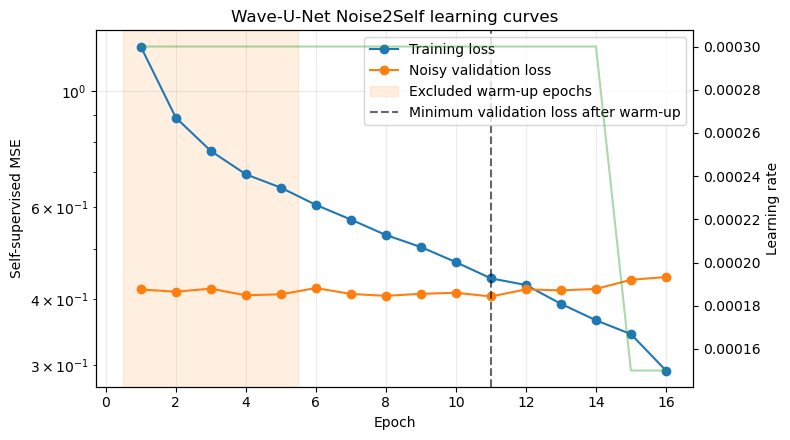

In [11]:
epochs = np.arange(1, len(history["train_loss"]) + 1)
fig, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(epochs, history["train_loss"], marker="o", label="Training loss")
axis.plot(
    epochs,
    history["validation_loss"],
    marker="o",
    label="Noisy validation loss",
)
axis.axvspan(
    0.5,
    MODEL_SELECTION_WARMUP_EPOCHS + 0.5,
    color="tab:orange",
    alpha=0.12,
    label="Excluded warm-up epochs",
)
axis.axvline(
    best_epoch,
    color="black",
    linestyle="--",
    alpha=0.6,
    label="Minimum validation loss after warm-up",
)
axis.set_yscale("log")
axis.set_xlabel("Epoch")
axis.set_ylabel("Self-supervised MSE")
axis.set_title("Wave-U-Net Noise2Self learning curves")
axis.grid(alpha=0.25)
axis.legend()

learning_rate_axis = axis.twinx()
learning_rate_axis.plot(
    epochs,
    history["learning_rate"],
    color="tab:green",
    alpha=0.4,
    label="Learning rate",
)
learning_rate_axis.set_ylabel("Learning rate")
plt.tight_layout()
plt.show()

## 5. Full-gather inference and checkpoint verification

The selected model predicts all complete receiver traces. The checkpoint
contains the model and reconstruction metadata, but the denoised gather is
not written to a binary file.

In [12]:
def predict_normalized_gather(trained_model, model_inputs, batch_size=10):
    trained_model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, model_inputs.shape[0], batch_size):
            stop = min(start + batch_size, model_inputs.shape[0])
            x_batch = torch.from_numpy(model_inputs[start:stop]).to(
                DEVICE, non_blocking=True
            )
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=AMP_ENABLED,
            ):
                prediction = trained_model(x_batch)
            predictions.append(
                prediction.squeeze(1).float().cpu().numpy()
            )
    return np.ascontiguousarray(
        np.concatenate(predictions, axis=0), dtype=np.float32
    )


denoised_normalized = predict_normalized_gather(
    model, neighbor_inputs, INFERENCE_BATCH_SIZE
)
denoised = (
    denoised_normalized.astype(np.float64) * normalization_scale
    + normalization_mean
)
denoised_float32 = np.ascontiguousarray(denoised, dtype=np.float32)
removed_component = (
    noisy.astype(np.float64) - denoised_float32.astype(np.float64)
)

assert denoised_normalized.shape == (N_TRACES, N_SAMPLES)
assert denoised_float32.shape == noisy.shape
assert np.isfinite(denoised_float32).all()

checkpoint = {
    "model_state_dict": best_state,
    "normalization_mean": normalization_mean,
    "normalization_scale": normalization_scale,
    "model_config": copy.deepcopy(MODEL_CONFIG),
    "config": {
        "seed": SEED,
        "n_traces": N_TRACES,
        "n_samples": N_SAMPLES,
        "dt": DT,
        "receiver_offsets": RECEIVER_OFFSETS,
        "boundary_convention": (
            "zero-filled unavailable offsets plus availability masks"
        ),
        "train_end": TRAIN_END,
        "validation_start": VALIDATION_START,
        "train_patch_length": TRAIN_PATCH_LENGTH,
        "train_patch_stride": TRAIN_PATCH_STRIDE,
        "validation_patch_length": VALIDATION_PATCH_LENGTH,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "gradient_clip_norm": GRADIENT_CLIP_NORM,
        "selection_rule": "minimum noisy validation loss after warm-up",
        "model_selection_warmup_epochs": MODEL_SELECTION_WARMUP_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "best_epoch": best_epoch,
        "best_validation_loss": best_validation_loss,
        "training_seconds": training_seconds,
    },
    "provenance": {
        "source_repository": SOURCE_REPOSITORY,
        "source_commit": SOURCE_COMMIT,
        "adaptation": (
            "Nine-scale PyTorch Wave-U-Net with 16 masked-neighbour "
            "inputs, one linear hidden-receiver output, same padding, "
            "receiver-held-out Noise2Self training on the supplied "
            "noisy seismic gather."
        ),
    },
    "history": history,
}
torch.save(checkpoint, CHECKPOINT_PATH)

assert CHECKPOINT_PATH.is_file()
assert CHECKPOINT_PATH.stat().st_size > 0
print(f"Denoised shape: {denoised_float32.shape}")
print(
    "Denoised RMS: "
    f"{np.sqrt(np.mean(denoised.astype(np.float64) ** 2)):.8g}"
)
print(
    "Removed-component RMS: "
    f"{np.sqrt(np.mean(removed_component ** 2)):.8g}"
)
print(f"Saved checkpoint: {CHECKPOINT_PATH.resolve()}")
print(f"Checkpoint size: {CHECKPOINT_PATH.stat().st_size:,} bytes")
print("No denoised binary file was written.")

Denoised shape: (100, 4000)
Denoised RMS: 0.019270362
Removed-component RMS: 0.015854702
Saved checkpoint: /mnt/drive/adarsh/MBD/Denoise_master/waveunet_noise2self_noisy_input_model.pt
Checkpoint size: 18,537,807 bytes
No denoised binary file was written.


In [13]:
# Reload the checkpoint and require exactly identical full-gather output.
reloaded_checkpoint = torch.load(
    CHECKPOINT_PATH, map_location="cpu", weights_only=False
)
reloaded_model = WaveUNetNoise2Self(
    **reloaded_checkpoint["model_config"]
)
reloaded_model.load_state_dict(reloaded_checkpoint["model_state_dict"])
reloaded_model = reloaded_model.to(DEVICE).eval()

reloaded_normalized = predict_normalized_gather(
    reloaded_model, neighbor_inputs, INFERENCE_BATCH_SIZE
)
maximum_reload_difference = float(
    np.max(np.abs(reloaded_normalized - denoised_normalized))
)
assert np.array_equal(reloaded_normalized, denoised_normalized)

print(
    "Maximum checkpoint-reload output difference: "
    f"{maximum_reload_difference:.3g}"
)
print("Exact full-gather checkpoint reload verified.")

Maximum checkpoint-reload output difference: 0
Exact full-gather checkpoint reload verified.


## 6. No-reference diagnostics and all-receiver J-invariance

These diagnostics are completed before the clean reference is loaded.

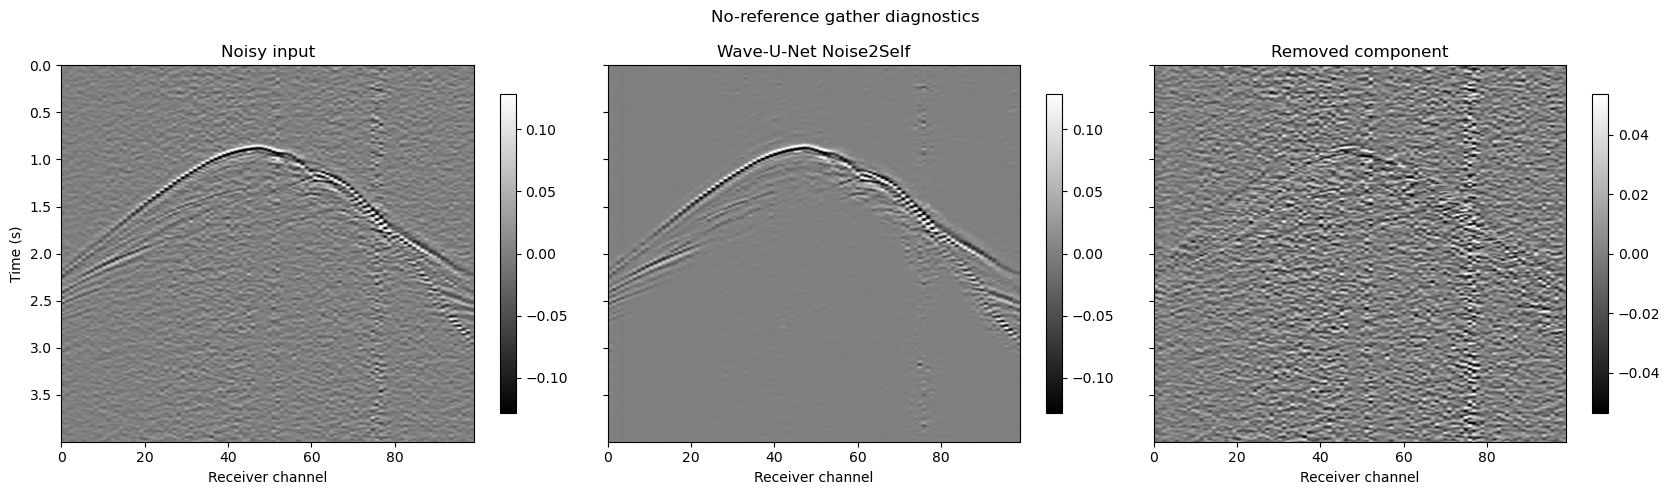

In [14]:
gather_clip = np.quantile(
    np.abs(np.concatenate((noisy, denoised_float32), axis=0)), 0.995
)
removed_clip = np.quantile(np.abs(removed_component), 0.995)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for axis, (gather, title, panel_clip) in zip(
    axes,
    [
        (noisy, "Noisy input", gather_clip),
        (denoised_float32, "Wave-U-Net Noise2Self", gather_clip),
        (removed_component, "Removed component", removed_clip),
    ],
):
    image = axis.imshow(
        gather.T,
        aspect="auto",
        cmap="gray",
        vmin=-panel_clip,
        vmax=panel_clip,
        extent=[0, N_TRACES - 1, time_s[-1], time_s[0]],
    )
    axis.set_title(title)
    axis.set_xlabel("Receiver channel")
    fig.colorbar(image, ax=axis, shrink=0.85)
axes[0].set_ylabel("Time (s)")
fig.suptitle("No-reference gather diagnostics")
plt.tight_layout()
plt.show()

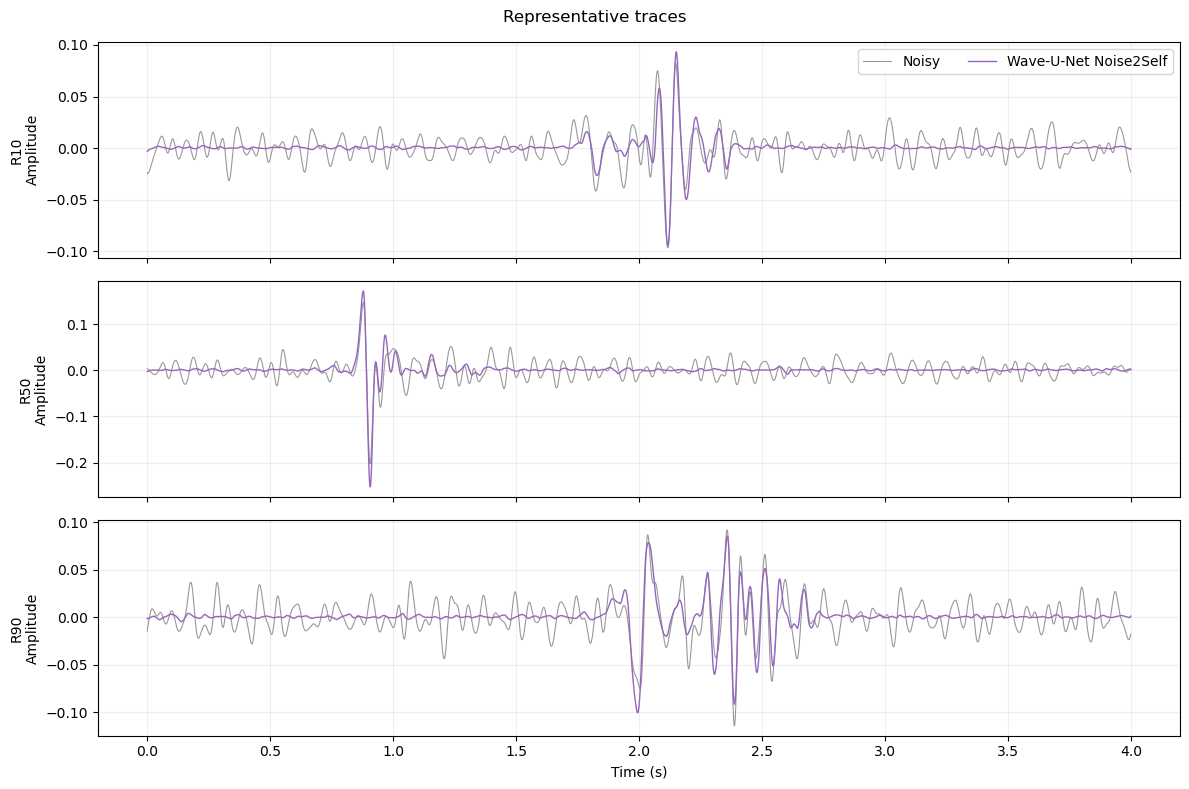

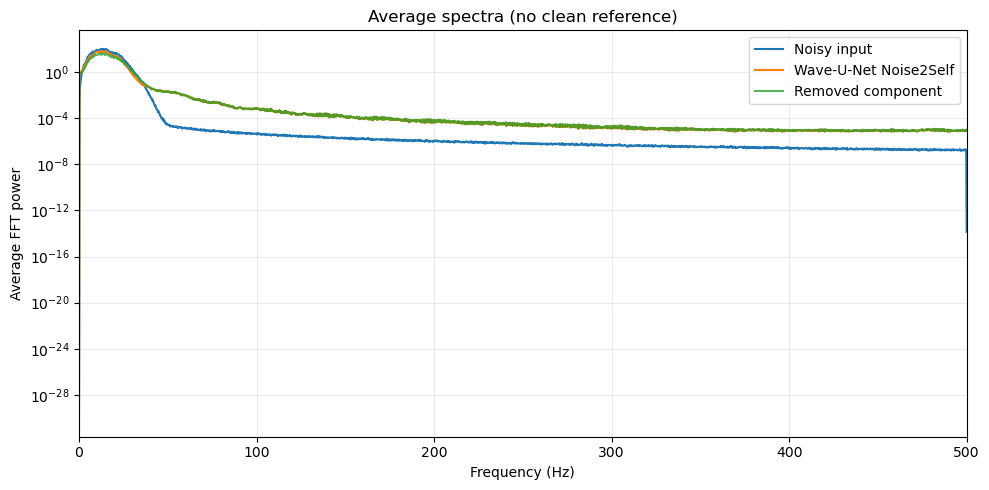

In [15]:
representative_receivers = [10, 50, 90]
fig, axes = plt.subplots(
    len(representative_receivers), 1, figsize=(12, 8), sharex=True
)
for axis, receiver in zip(axes, representative_receivers):
    axis.plot(
        time_s,
        noisy[receiver],
        color="0.6",
        linewidth=0.8,
        label="Noisy",
    )
    axis.plot(
        time_s,
        denoised_float32[receiver],
        color="tab:purple",
        linewidth=1.0,
        label="Wave-U-Net Noise2Self",
    )
    axis.set_ylabel(f"R{receiver}\nAmplitude")
    axis.grid(alpha=0.2)
axes[0].legend(ncol=2)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Representative traces")
plt.tight_layout()
plt.show()


def average_power_spectrum(traces):
    centered = traces.astype(np.float64) - traces.mean(
        axis=1, keepdims=True, dtype=np.float64
    )
    spectrum = np.fft.rfft(centered, axis=1)
    return np.mean(np.abs(spectrum) ** 2, axis=0)


frequencies_hz = np.fft.rfftfreq(N_SAMPLES, d=DT)
noisy_psd = average_power_spectrum(noisy)
denoised_psd = average_power_spectrum(denoised_float32)
removed_psd = average_power_spectrum(removed_component)

plt.figure(figsize=(10, 5))
plt.semilogy(frequencies_hz, noisy_psd, label="Noisy input")
plt.semilogy(
    frequencies_hz, denoised_psd, label="Wave-U-Net Noise2Self"
)
plt.semilogy(
    frequencies_hz, removed_psd, label="Removed component", alpha=0.8
)
plt.xlim(0, 500)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Average FFT power")
plt.title("Average spectra (no clean reference)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Model-level J-invariance for all 100 target receivers.
original_target_predictions = predict_normalized_gather(
    reloaded_model, neighbor_inputs, INFERENCE_BATCH_SIZE
)
perturbed_target_predictions = predict_normalized_gather(
    reloaded_model, perturbed_target_inputs, INFERENCE_BATCH_SIZE
)
maximum_prediction_difference = float(
    np.max(
        np.abs(
            original_target_predictions - perturbed_target_predictions
        )
    )
)

assert maximum_target_input_difference == 0.0
assert maximum_prediction_difference == 0.0
print("J-invariance verified for all 100 receivers.")
print(
    "Maximum input difference: "
    f"{maximum_target_input_difference:.3g}"
)
print(
    "Maximum prediction difference: "
    f"{maximum_prediction_difference:.3g}"
)

J-invariance verified for all 100 receivers.
Maximum input difference: 0
Maximum prediction difference: 0


## 7. Final clean-reference evaluation

Training, model selection, inference, checkpoint persistence/reload, and
J-invariance verification are already complete. The clean reference is loaded
below only to evaluate the synthetic result.


In [17]:
clean_raw = np.fromfile(CLEAN_REFERENCE_PATH, dtype=DTYPE)
if clean_raw.size != EXPECTED_VALUES:
    raise ValueError(
        f"Expected {EXPECTED_VALUES:,} clean values, "
        f"found {clean_raw.size:,}."
    )
if not np.isfinite(clean_raw).all():
    raise ValueError("The clean reference contains NaN or infinite values.")

clean_reference = clean_raw.reshape(N_TRACES, N_SAMPLES)
assert clean_reference.shape == noisy.shape == denoised_float32.shape

print(
    "Clean reference loaded for final evaluation only: "
    f"{CLEAN_REFERENCE_PATH.resolve()}"
)


Clean reference loaded for final evaluation only: /mnt/drive/adarsh/MBD/Denoise_master/dmulti_receiver_data.bin


In [18]:
def reference_metrics(estimate, reference):
    estimate64 = np.asarray(estimate, dtype=np.float64)
    reference64 = np.asarray(reference, dtype=np.float64)
    reference_centered = (
        reference64 - reference64.mean(axis=1, keepdims=True)
    )
    error = estimate64 - reference64

    signal_power_per_trace = np.mean(reference_centered ** 2, axis=1)
    error_power_per_trace = np.mean(error ** 2, axis=1)
    snr_per_trace_db = 10.0 * np.log10(
        signal_power_per_trace / error_power_per_trace
    )

    signal_energy = np.sum(reference_centered ** 2)
    error_energy = np.sum(error ** 2)
    rmse = np.sqrt(np.mean(error ** 2))
    reference_rms = np.sqrt(np.mean(reference_centered ** 2))

    return {
        "snr_db": 10.0 * np.log10(signal_energy / error_energy),
        "rmse": rmse,
        "mae": np.mean(np.abs(error)),
        "nrmse_percent": 100.0 * rmse / reference_rms,
        "correlation": np.corrcoef(
            reference64.ravel(), estimate64.ravel()
        )[0, 1],
        "snr_per_trace_db": snr_per_trace_db,
    }


noisy_metrics = reference_metrics(noisy, clean_reference)
waveunet_metrics = reference_metrics(
    denoised_float32, clean_reference
)

print(
    "Full-reference results (training and selection used noisy data only)"
)
print("-" * 80)
print(
    f"{'Metric':<24}{'Noisy input':>18}"
    f"{'Wave-U-Net N2S':>22}{'Change':>16}"
)
print("-" * 80)
for label, key in [
    ("Global SNR (dB)", "snr_db"),
    ("RMSE", "rmse"),
    ("MAE", "mae"),
    ("Normalized RMSE (%)", "nrmse_percent"),
    ("Correlation", "correlation"),
]:
    noisy_value = noisy_metrics[key]
    model_value = waveunet_metrics[key]
    print(
        f"{label:<24}{noisy_value:>18.6f}"
        f"{model_value:>22.6f}"
        f"{model_value - noisy_value:>+16.6f}"
    )
print("-" * 80)

improved_receivers = np.count_nonzero(
    waveunet_metrics["snr_per_trace_db"]
    > noisy_metrics["snr_per_trace_db"]
)
denoising_pass = (
    waveunet_metrics["snr_db"] > noisy_metrics["snr_db"]
)
print(
    "Denoising acceptance criterion (global SNR above noisy input): "
    + ("PASS" if denoising_pass else "FAIL")
)
print(f"Receivers with improved SNR: {improved_receivers} of {N_TRACES}")

Full-reference results (training and selection used noisy data only)
--------------------------------------------------------------------------------
Metric                         Noisy input        Wave-U-Net N2S          Change
--------------------------------------------------------------------------------
Global SNR (dB)                   2.000000              7.309893       +5.309893
RMSE                              0.014785              0.008023       -0.006762
MAE                               0.011216              0.004162       -0.007054
Normalized RMSE (%)              79.432823             43.102787      -36.330036
Correlation                       0.785022              0.911362       +0.126340
--------------------------------------------------------------------------------
Denoising acceptance criterion (global SNR above noisy input): PASS
Receivers with improved SNR: 100 of 100


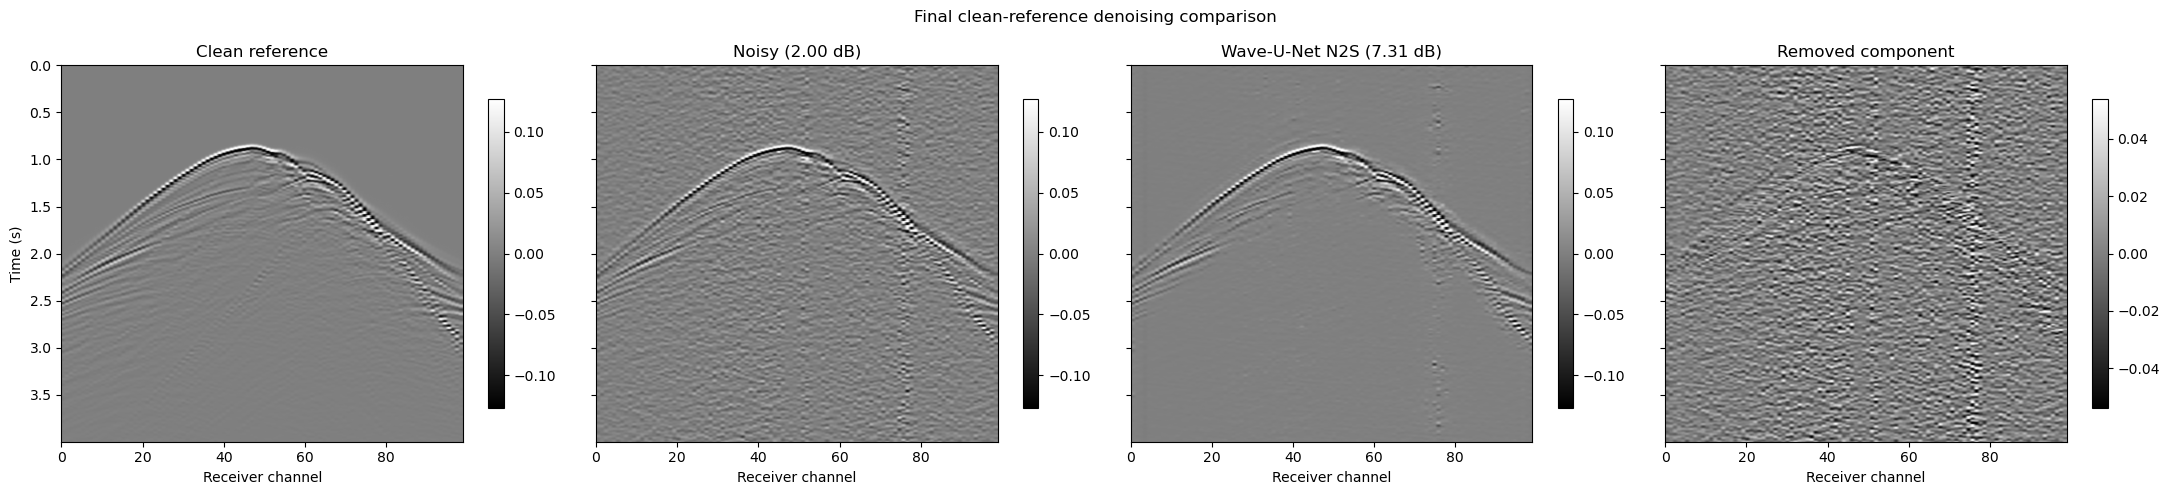

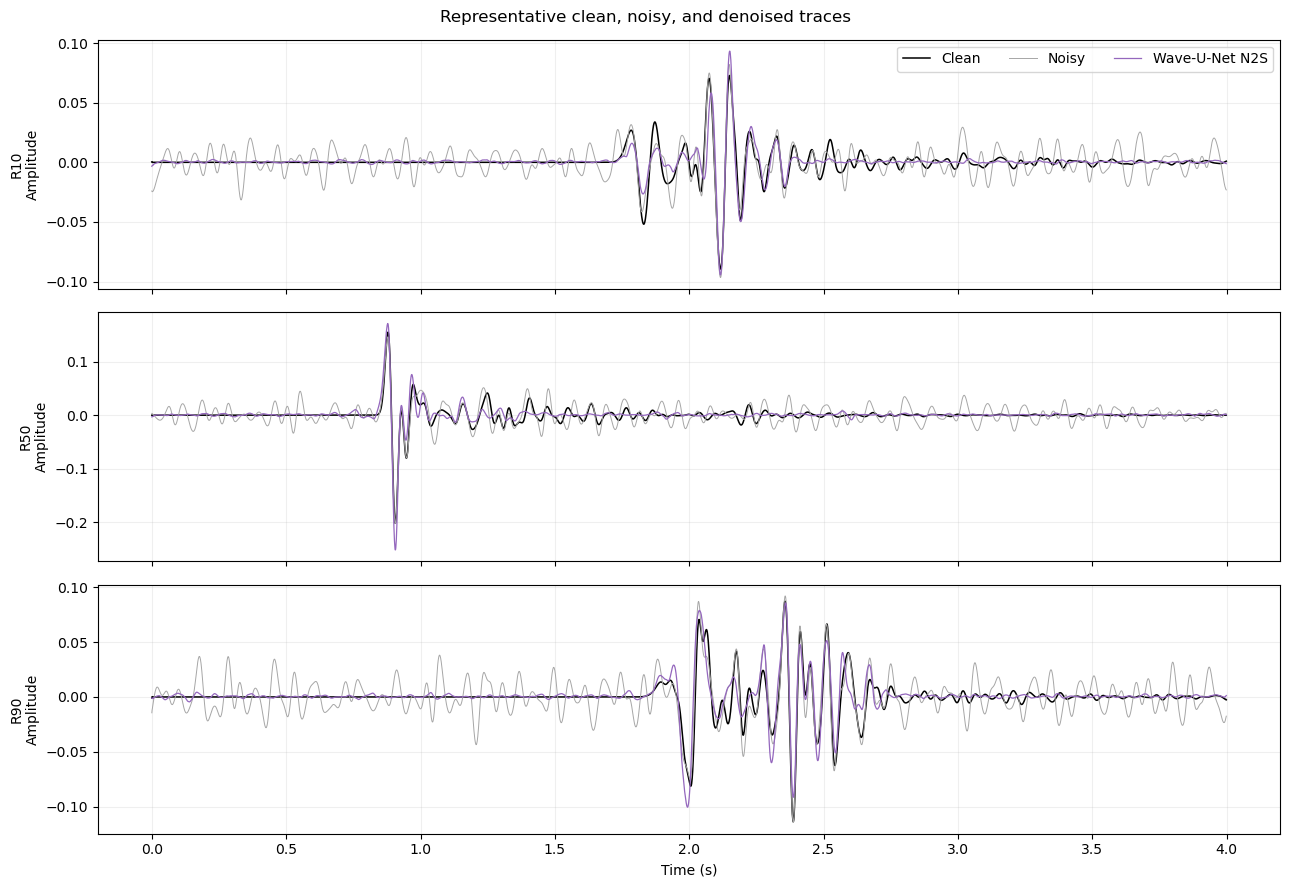

In [19]:
comparison_clip = np.quantile(
    np.abs(np.concatenate((clean_reference, noisy, denoised_float32), axis=0)),
    0.995,
)
removed_clip = np.quantile(np.abs(removed_component), 0.995)
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
panels = [
    (clean_reference, "Clean reference", comparison_clip),
    (noisy, f"Noisy ({noisy_metrics['snr_db']:.2f} dB)", comparison_clip),
    (
        denoised_float32,
        f"Wave-U-Net N2S ({waveunet_metrics['snr_db']:.2f} dB)",
        comparison_clip,
    ),
    (removed_component, "Removed component", removed_clip),
]
for axis, (gather, title, panel_clip) in zip(axes, panels):
    image = axis.imshow(
        gather.T,
        aspect="auto",
        cmap="gray",
        vmin=-panel_clip,
        vmax=panel_clip,
        extent=[0, N_TRACES - 1, time_s[-1], time_s[0]],
    )
    axis.set_title(title)
    axis.set_xlabel("Receiver channel")
    fig.colorbar(image, ax=axis, shrink=0.82)
axes[0].set_ylabel("Time (s)")
fig.suptitle("Final clean-reference denoising comparison")
plt.tight_layout()
plt.show()

representative_receivers = [10, 50, 90]
fig, axes = plt.subplots(
    len(representative_receivers), 1, figsize=(13, 9), sharex=True
)
for axis, receiver in zip(axes, representative_receivers):
    axis.plot(time_s, clean_reference[receiver], color="black", linewidth=1.1, label="Clean")
    axis.plot(time_s, noisy[receiver], color="0.65", linewidth=0.7, label="Noisy")
    axis.plot(
        time_s,
        denoised_float32[receiver],
        color="tab:purple",
        linewidth=0.9,
        label="Wave-U-Net N2S",
    )
    axis.set_ylabel(f"R{receiver}\nAmplitude")
    axis.grid(alpha=0.2)
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Representative clean, noisy, and denoised traces")
plt.tight_layout()
plt.show()


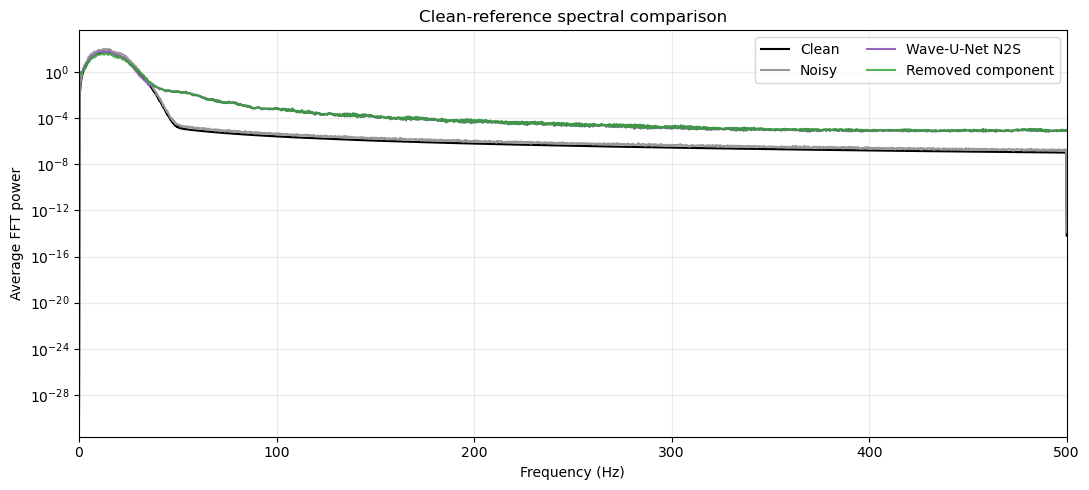

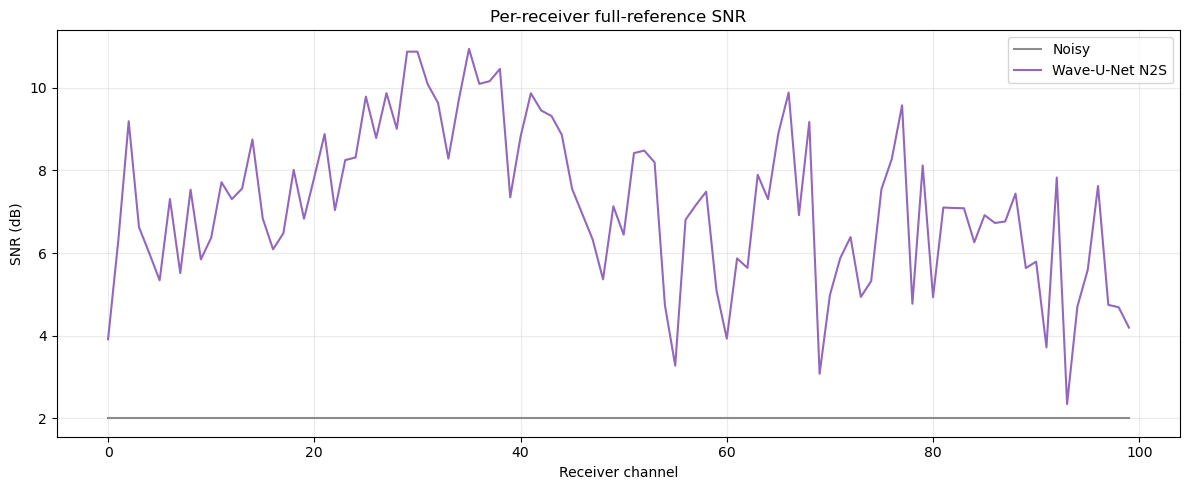

In [20]:
clean_psd = average_power_spectrum(clean_reference)
plt.figure(figsize=(11, 5))
plt.semilogy(frequencies_hz, clean_psd, color="black", label="Clean")
plt.semilogy(frequencies_hz, noisy_psd, color="0.6", label="Noisy")
plt.semilogy(
    frequencies_hz, denoised_psd, color="tab:purple", label="Wave-U-Net N2S"
)
plt.semilogy(
    frequencies_hz, removed_psd, color="tab:green", alpha=0.8, label="Removed component"
)
plt.xlim(0, 500)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Average FFT power")
plt.title("Clean-reference spectral comparison")
plt.grid(alpha=0.25)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

receiver_indices = np.arange(N_TRACES)
plt.figure(figsize=(12, 5))
plt.plot(receiver_indices, noisy_metrics["snr_per_trace_db"], color="0.55", label="Noisy")
plt.plot(
    receiver_indices,
    waveunet_metrics["snr_per_trace_db"],
    color="tab:purple",
    label="Wave-U-Net N2S",
)
plt.xlabel("Receiver channel")
plt.ylabel("SNR (dB)")
plt.title("Per-receiver full-reference SNR")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


## Interpretation

The Wave-U-Net estimates each complete target trace only from fixed-offset
neighbouring receivers and availability masks. The target trace never appears
in its own input, including at gather edges, so the Noise2Self objective cannot
directly copy its noise.

The clean reference was not available to normalization, optimization,
validation, early stopping, checkpoint selection, or inference.
